# Detection of hate messages on Twitter with tweepy:
This is a notebook demonstrating extraction of tweets from tweeter and analysing the sentiment of the same by using a python library named textblob. Its an interesting library for processing textual data for NLP tasks such as parts of speech tagging, sentiment analysis, classification, translation and more. I am dividing the notebook in Five parts
* Setting up authentication API with Tweeter
* **handling of environment variables such as tweeter api keys and acess token in kaggle notebook**
* Extracting tweets
* Pre-processing extracted tweets
* Sentiment analysis

In this notebook, the sentiment analysis is done using only python libraries. Regex is used to clean the tweets.


## 1. Getting Access keys from tweeter for authentication
To extract tweets from tweeter we need to first get registered as developer in tweeter in the following tweeter developer portal
https://developer.twitter.com/en/docs/authentication/guides/log-in-with-twitter

We need to fill up an application post review and approval we will be provided with the access keys required to access tweets programatically. There are monthly limits for no of tweets that can be extracted. The process took a week for me.
* Access_token &
* Access_token_secret

are for authenticating the user(developer)
There are an another pair of api keys which is application specific as a user can have multiple apps that may need programatic access. these keys are
* consumer_key
* consumer_secret


## 2. Handling of environment variables such as tweeter api keys and acess token in kaggle notebook

Now since we have all the API keys we need to extract tweets, its time to find a way to handle them in the notebook without making them public. For this Kaggle has a feature called **Secrets** under **add-ons**** section of the menu.
We can add these keys in the secrets section and can have access to them using kaggles **kaggle_secrets** library & its UserSecretsClient class



In [ ]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
access_token = user_secrets.get_secret("access_token")
access_token_secret = user_secrets.get_secret("access_token_secret")
consumer_key = user_secrets.get_secret("consumer_key")
consumer_secret = user_secrets.get_secret("consumer_secret")

In [ ]:
pip install tweepy

You should consider upgrading via the '/opt/conda/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


### 3. Extracting tweets

To extract tweets using the API keys we will use a python library named **tweepy**. Twitter requires all requests to use OAuth for authentication.The API class of tweepy provides access to the entire twitter RESTful API methods. Each method can accept various parameters and return responses. For more information please go to the link below:
http://docs.tweepy.org/en/latest/api.html#api-reference

Below we are extracting 100 tweets from Billgates The tweepy object (api) that we created takes three arguments screen name of the person whose tweets we want to extract, no of tweets we want to extract and tweet mode.


In [ ]:
import tweepy

consumer_key= BmJaVKHd0VoCcGszpKu9QTh7n
consumer_secret= Ok8AtkGKI0kWzPrzZ8b8v6lQHGQSQeyGkNo8PdzgK9wn3uHYYk
access_token=  1866923216037437441-XmkOSSsFZawMcp0ajzb45MAjZkwIjQ
access_token_secret= WxfPkwL8wr9vVXatcY02nk1UGyfxqqIA3widhN2Kq0l2T

auth = tweepy.OAuthHandler(consumer_key, consumer_secret)

auth.set_access_token(access_token, access_token_secret)

api = tweepy.API(auth)
# extracting 100 tweets from BillGates account

# public_tweets = api.home_timeline()
tweets=api.user_timeline(screen_name="BillGates",count=100,tweet_mode="extended")
# lets check the number of tweets extracted
print(f"No of tweets exracted:{len(tweets)}")




No of tweets exracted:100


In [ ]:
print(type(tweets))
print(f"No of tweets exracted:{len(tweets)}")

i = 1
# print(moditweets[0].text)
for tweet in tweets[:10]:
    print(str(i) + ') ' + tweet.full_text + "\n")
    print("---------Next tweet below---------")
    i+=1

<class 'tweepy.models.ResultSet'>
No of tweets exracted:100
1) Congratulations @AndrewSteerWRI on this important role. I’m excited to see what you and the Earth Fund will achieve. Avoiding a climate disaster is going to take all of us, and I’m grateful for @JeffBezos’s leadership and partnership. https://t.co/QSMBMtfUI1

---------Next tweet below---------
2) Thank you @SalKhanAcademy for a great conversation about climate change and thanks to @BookPeople and @BlueWillowBooks for hosting the event. https://t.co/mHQ2Adqkro

---------Next tweet below---------
3) For decades, Australian researcher Ruth Bishop led global efforts to identify and combat rotavirus. Her life is a reminder of the importance of scientific research to uncover unknown pathogens and the power of vaccines to prevent suffering and save lives. https://t.co/X5okWwpBbX

---------Next tweet below---------
4) RT @GlobalFund: Speaking from villages, riverbanks and rural clinics, frontline health workers and malaria voluntee

In [ ]:
import pandas as pd
import re

In [ ]:
# creating a dataframe

df = pd.DataFrame([tweet.full_text for tweet in tweets], columns = ['tweet'])
df.head()

,tweet
0,Congratulations @AndrewSteerWRI on this import...
1,Thank you @SalKhanAcademy for a great conversa...
2,"For decades, Australian researcher Ruth Bishop..."
3,"RT @GlobalFund: Speaking from villages, riverb..."
4,Virologist Ruth Bishop pioneered the research ...


In [ ]:
df[0:5]

,tweet
0,Congratulations @AndrewSteerWRI on this import...
1,Thank you @SalKhanAcademy for a great conversa...
2,"For decades, Australian researcher Ruth Bishop..."
3,"RT @GlobalFund: Speaking from villages, riverb..."
4,Virologist Ruth Bishop pioneered the research ...


## 4. Pre-processing

* cleaning of the tweets
* remove the @ symbol
* remove hashtags
* remove RT retweeets

In [ ]:
def CleanTxt(text):
    text = re.sub(r'@[\w]+','',text)
    text = re.sub(r'#','',text)
    text = re.sub(r'RT[\s]+','',text) # \s for space and + for one or more
    text = re.sub(r'https?:\/\/\S+', '', text)
    return text

In [ ]:
sample = tweets[1].full_text
sample

'Thank you @SalKhanAcademy for a great conversation about climate change and thanks to @BookPeople and @BlueWillowBooks for hosting the event. https://t.co/mHQ2Adqkro'

In [ ]:
# tweet after cleaning
print(CleanTxt(sample))

Thank you  for a great conversation about climate change and thanks to  and  for hosting the event. 


In [ ]:
# Cleaning the tweets by applying the function to the dataframe

df['tweet'] = df['tweet'].apply(CleanTxt)

In [ ]:
df.tail()

,tweet
95,"In our first podcast episode, Rashida Jones an..."
96,More than 7 million community health workers s...
97,: No one is safe from COVID-19 until everyone ...
98,"Each week, we’ll talk about some of the bigges..."
99,I’m teaming up with Rashida Jones to ask the b...


# 5. Sentiment Analysis

In [ ]:
# textBlob is a python library  for text processing. It provides a simple API to dive in to NLP tasks such as sentiment analysis, translation, parts of speech tagging etc
# read more on https://textblob.readthedocs.io/en/dev/
#it gives us a blob = textBlob(text) and we can extract tags, noun-phrases, sentences by utilizing methods blob.tags, blob.noun-phrases, blob.sentences
#will create two functions to extract subjectivity and polarity of the tweets using the textblbo library

from textblob import TextBlob

def getSubjectivity(text):
    # will get the subjectivity of the tweet
    blob = TextBlob(text)
    return blob.sentiment.subjectivity
def getPolarity(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity


In [ ]:
# Creating two columns/serieses in the dataframe subjecticity and polarity
df['subjectivity'] = df['tweet'].apply(getSubjectivity)
df['polarity'] = df['tweet'].apply(getPolarity)
df

,tweet,subjectivity,polarity
0,Congratulations on this important role. I’m e...,0.875000,0.387500
1,Thank you for a great conversation about clim...,0.475000,0.500000
2,"For decades, Australian researcher Ruth Bishop...",0.200000,-0.033333
3,": Speaking from villages, riverbanks and rural...",0.000000,0.000000
4,Virologist Ruth Bishop pioneered the research ...,0.637500,0.287500
...,...,...,...
95,"In our first podcast episode, Rashida Jones an...",0.333333,0.250000
96,More than 7 million community health workers s...,0.633333,0.533333
97,: No one is safe from COVID-19 until everyone ...,0.500000,0.500000
98,"Each week, we’ll talk about some of the bigges...",0.571429,0.357143


# Visualizing the tweets using a tag cloud
This is one of my favourite part. The tag cloud is very expressive and simple. From the below tag cloud we can see that most of the time Bill Gates tweeted about **Covid, Climate Change, Pandemic, Health  issues**

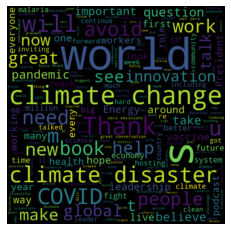

In [ ]:
# preparing a tag or word cloud using the WordCloud library
# wordcloud is a MIT lisensed library.
from wordcloud import WordCloud
import matplotlib.pyplot as plt
allWords = ' '.join([tweet for tweet in df['tweet']])
wordCloud = WordCloud(width = 600, height = 600, max_font_size = 120, random_state = 20).generate(allWords)
plt.imshow(wordCloud, interpolation = 'bilinear')
plt.axis('off')
plt.savefig('wordcloud.png')
plt.show()


In [ ]:
# Creating a new function for converting the score into positive, negative and neutral sentiment.

def sentiment_analysis(score):
    if score < 0:
        return 'Negative'
    elif score == 0:
        return 'Neutral'
    else:
        return 'Positive'


In [ ]:
# checking the function
sentiment_analysis(-0.987)

'Negative'

In [ ]:
# Creating a new column with the sentiment of  the tweet  by applying the above defined function to the polarity column

df['sentiment'] = df['polarity'].apply(sentiment_analysis)

In [ ]:
df.tail()

,tweet,subjectivity,polarity,sentiment
95,"In our first podcast episode, Rashida Jones an...",0.333333,0.250000,Positive
96,More than 7 million community health workers s...,0.633333,0.533333,Positive
97,: No one is safe from COVID-19 until everyone ...,0.500000,0.500000,Positive
98,"Each week, we’ll talk about some of the bigges...",0.571429,0.357143,Positive
99,I’m teaming up with Rashida Jones to ask the b...,0.199351,0.016234,Positive


In [ ]:
# Now, lets group the tweets sentiment wise to see the proportions of the tweets with each sentiment.
sentiment_count = df.groupby('sentiment').sentiment.count()
sentiment_count
# we have 76 positive tweets, 18 neutral and 6 negative tweets as per the sentiment analysis. These numbers may change with newer tweets

sentiment
Negative    12
Neutral     12
Positive    76
Name: sentiment, dtype: int64

In [ ]:
# Now I want to  sort the tweets based on their positivity score.
# First sort the dataframe based on the score

sorted_df = df.sort_values(by  = ['polarity'])
# j = 1
# for i in range(sorted_df.shape[0]):
#     if sorted_df['sentiment'][i] == 'Positive':
#         print(str(j)+ ') ' + df['tweet'])
#         print()
#         j+=1

print(type(sorted_df))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
# positive_df = sorted_df[sorted_df.where(sorted_df['sentiment'] =='Positive', inplace = True)]
positive_df = sorted_df[sorted_df['sentiment'] == 'Positive']
print(type(positive_df))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
drop =positive_df.reset_index(drop = True)
# drop[tweet]
drop['tweet'].count()
# print(type(drop))

76

In [ ]:
# Displaying the positive tweets
ps = df[df['sentiment']=='Positive']
ps

,tweet,subjectivity,polarity,sentiment
0,Congratulations on this important role. I’m e...,0.875000,0.387500,Positive
1,Thank you for a great conversation about clim...,0.475000,0.500000,Positive
4,Virologist Ruth Bishop pioneered the research ...,0.637500,0.287500,Positive
5,": On International Women’s Day, join me in cel...",0.666667,0.166667,Positive
6,Thank you for the kind words. Your leadership...,0.633333,0.200000,Positive
...,...,...,...,...
95,"In our first podcast episode, Rashida Jones an...",0.333333,0.250000,Positive
96,More than 7 million community health workers s...,0.633333,0.533333,Positive
97,: No one is safe from COVID-19 until everyone ...,0.500000,0.500000,Positive
98,"Each week, we’ll talk about some of the bigges...",0.571429,0.357143,Positive


# Thank You